##Building local model on Shakespeare data

In [2]:
# ============================================================
# PyTorch Setup
# ------------------------------------------------------------
# This cell imports all required libraries, checks whether
# a GPU is available, and selects the appropriate device
# (CUDA GPU or CPU) for training deep learning models.
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import time
import os

# Select GPU if available, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")

# Print GPU name if CUDA is available
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


##Load Tiny Shakespeare Dataset

In [3]:
# ============================================================
# Load Tiny Shakespeare Dataset
# ------------------------------------------------------------
# Download the dataset if it does not already exist.
# Then read the entire text file into memory.
# ============================================================

DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

# Download dataset only once
if not os.path.exists("shakespeare.txt"):
    import urllib.request
    urllib.request.urlretrieve(DATA_URL, "shakespeare.txt")

# Read dataset
with open("shakespeare.txt", "r", encoding="utf-8") as f:
    text = f.read()

# Display dataset statistics
print(f"Total characters: {len(text):,}")
print("\nFirst 200 characters:\n")
print(text[:200])

Total characters: 1,115,394

First 200 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


## Build character vocabulary

## Next time use byte pair encoding

In [4]:
# Build character vocabulary
chars = sorted(set(text))
vocab_size = len(chars)

# Character <-> Integer mappings
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

# Encode/decode helpers
def encode(s):
    return [char_to_idx[c] for c in s]

def decode(ids):
    return "".join([idx_to_char[i] for i in ids])

print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {''.join(chars)}")

print(f"\nExample encoding:")
print(f"'Hello' -> {encode('Hello')}")
print(f"{encode('Hello')} -> '{decode(encode('Hello'))}'")

Vocabulary size: 65
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz

Example encoding:
'Hello' -> [20, 43, 50, 50, 53]
[20, 43, 50, 50, 53] -> 'Hello'


## Convert Entire Dataset to Tensor

In [5]:
# Train/val split (90/10)
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))

train_data = data[:n]
val_data = data[n:]

print(f"Training tokens: {len(train_data):,}")
print(f"Validation tokens: {len(val_data):,}")

Training tokens: 1,003,854
Validation tokens: 111,540


##enerate random training batches for next-character prediction during model training.

In [6]:
def get_batch(split, batch_size, context_length):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - context_length, (batch_size,))

    x = torch.stack([d[i:i + context_length] for i in ix])
    y = torch.stack([d[i + 1:i + context_length + 1] for i in ix])

    return x.to(device), y.to(device)

# Quick test
xb, yb = get_batch("train", batch_size=4, context_length=8)

print(f"Input shape: {xb.shape} (batch_size x context_length)")
print(f"Target shape: {yb.shape}")

print(f"\nExample (first sequence):")
print(f"Input:  {decode(xb[0].tolist())!r}")
print(f"Target: {decode(yb[0].tolist())!r}")
print(f"\n(Target is input shifted by 1 character)")

Input shape: torch.Size([4, 8]) (batch_size x context_length)
Target shape: torch.Size([4, 8])

Example (first sequence):
Input:  ' dancing'
Target: 'dancing '

(Target is input shifted by 1 character)


##RMSNorm: A simpler and faster alternative to LayerNorm that normalizes using only the Root Mean Square (RMS) value.

In [7]:
# ============================================================
# RMSNorm (Root Mean Square Normalization)
# ------------------------------------------------------------
# Simpler than LayerNorm:
# - No mean subtraction
# - No bias parameter
# - Normalizes using only RMS value
# - Faster and commonly used in modern LLMs
# ============================================================

class RMSNorm(nn.Module):
    """
    Root Mean Square Layer Normalization

    Formula:
        output = (x / RMS(x)) * weight

    where:
        RMS(x) = sqrt(mean(x^2) + eps)
    """

    def __init__(self, dim, eps=1e-6):
        super().__init__()

        self.eps = eps

        # Learnable scaling parameter
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):

        # Compute RMS across last dimension
        rms = torch.sqrt(
            x.pow(2).mean(dim=-1, keepdim=True) + self.eps
        )

        # Normalize and scale
        return (x / rms) * self.weight


# ============================================================
# Dropout
# ------------------------------------------------------------
# Randomly sets some values to zero during training.
# Helps prevent overfitting and improves generalization.
# ============================================================

DROPOUT = 0.2


# ============================================================
# Demo
# ------------------------------------------------------------
# Test RMSNorm on a random tensor
# ============================================================

demo_x = torch.randn(2, 4, 8)

norm = RMSNorm(8)

demo_out = norm(demo_x)

print("Input Shape :", demo_x.shape)
print("Output Shape:", demo_out.shape)

print("\nSample Output:")
print(demo_out[0])

Input Shape : torch.Size([2, 4, 8])
Output Shape: torch.Size([2, 4, 8])

Sample Output:
tensor([[-2.3989,  0.4003,  0.4323,  0.4474, -0.1462, -1.1717,  0.2428, -0.4948],
        [-0.0222, -0.0240,  0.0858, -0.9100,  1.1461,  1.2400, -1.7772, -1.0742],
        [-1.7589, -0.6147, -0.7379, -1.5980,  0.6625, -0.8724,  0.1161, -0.4653],
        [ 0.7167,  0.6646, -0.7732,  1.1387, -0.3248, -1.5472,  1.6249, -0.1023]],
       grad_fn=<SelectBackward0>)


###Explanation

RMSNorm scales activations based on their magnitude without subtracting the mean. This reduces computation while maintaining training stability. We also introduce Dropout, which randomly disables some neurons during training to prevent overfitting and improve generalization.


## Rotary Positional Embeddings (RoPE)


### Traditional positional embeddings add position information to token embeddings. RoPE instead rotates the Query (Q) and Key (K) vectors based on their position. This allows the attention mechanism to understand how far apart tokens are, improving long-range dependency learning in modern LLMs such as LLaMA.

In [8]:
# ============================================================
# Rotary Positional Embeddings (RoPE)
# ------------------------------------------------------------
# RoPE encodes position information by rotating Q and K
# vectors instead of adding positional embeddings.
#
# Benefits:
# - Better extrapolation to longer sequences
# - Captures relative positions naturally
# - Used in modern LLMs (LLaMA, Gemma, etc.)
# ============================================================

def precompute_rope_freqs(head_dim, max_seq_len, base=10000.0):
    """
    Precompute cosine and sine tables for RoPE.

    Each pair of dimensions gets a different rotation frequency.

    Low dimensions  -> Fast rotation (local patterns)
    High dimensions -> Slow rotation (long-range patterns)
    """

    freqs = 1.0 / (
        base ** (torch.arange(0, head_dim, 2).float() / head_dim)
    )

    positions = torch.arange(max_seq_len).float()

    # [max_seq_len, head_dim // 2]
    angles = torch.outer(positions, freqs)

    return torch.cos(angles), torch.sin(angles)


def apply_rope(x, cos, sin):
    """
    Apply Rotary Positional Embeddings.

    x shape:
        [batch, n_heads, seq_len, head_dim]

    cos, sin shape:
        [seq_len, head_dim // 2]
    """

    seq_len = x.shape[2]

    cos = cos[:seq_len].to(x.device)
    sin = sin[:seq_len].to(x.device)

    # Split even and odd dimensions
    x_even = x[..., ::2]
    x_odd = x[..., 1::2]

    # Add broadcast dimensions
    cos = cos.unsqueeze(0).unsqueeze(0)
    sin = sin.unsqueeze(0).unsqueeze(0)

    # Apply rotation
    rotated_even = x_even * cos - x_odd * sin
    rotated_odd = x_even * sin + x_odd * cos

    # Interleave dimensions back together
    x_out = torch.zeros_like(x)

    x_out[..., ::2] = rotated_even
    x_out[..., 1::2] = rotated_odd

    return x_out


# ============================================================
# Demo
# ============================================================

head_dim = 8
max_seq_len = 16

cos, sin = precompute_rope_freqs(
    head_dim=head_dim,
    max_seq_len=max_seq_len
)

# Random tensor
x = torch.randn(2, 4, 10, head_dim)

x_rope = apply_rope(x, cos, sin)

print("Input Shape :", x.shape)
print("Output Shape:", x_rope.shape)

Input Shape : torch.Size([2, 4, 10, 8])
Output Shape: torch.Size([2, 4, 10, 8])


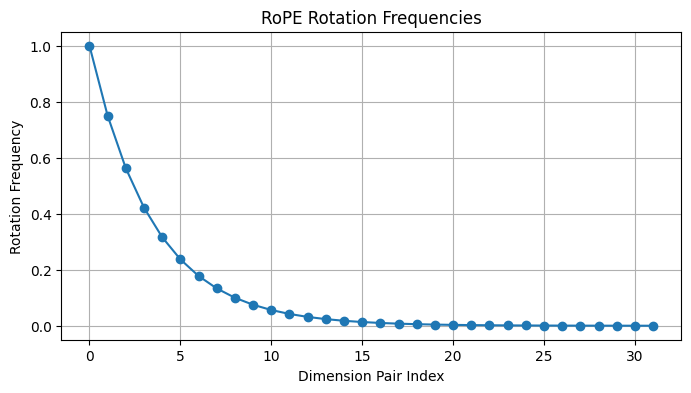

In [9]:
# ============================================================
# Visualize RoPE Rotation Frequencies
# ============================================================

head_dim = 64
base = 10000.0

# Frequency for each dimension pair
freqs = 1.0 / (
    base ** (torch.arange(0, head_dim, 2).float() / head_dim)
)

plt.figure(figsize=(8, 4))
plt.plot(freqs.numpy(), marker='o')

plt.title("RoPE Rotation Frequencies")
plt.xlabel("Dimension Pair Index")
plt.ylabel("Rotation Frequency")
plt.grid(True)

plt.show()

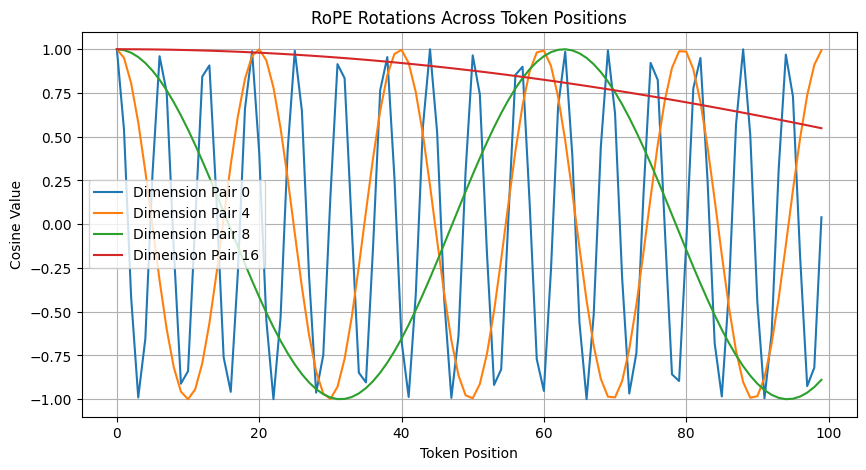

In [10]:
# ============================================================
# Visualize RoPE Rotations Over Positions
# ============================================================

head_dim = 64
max_seq_len = 100

cos, sin = precompute_rope_freqs(
    head_dim=head_dim,
    max_seq_len=max_seq_len
)

plt.figure(figsize=(10, 5))

for dim_idx in [0, 4, 8, 16]:
    plt.plot(
        cos[:, dim_idx],
        label=f"Dimension Pair {dim_idx}"
    )

plt.title("RoPE Rotations Across Token Positions")
plt.xlabel("Token Position")
plt.ylabel("Cosine Value")
plt.legend()
plt.grid(True)

plt.show()

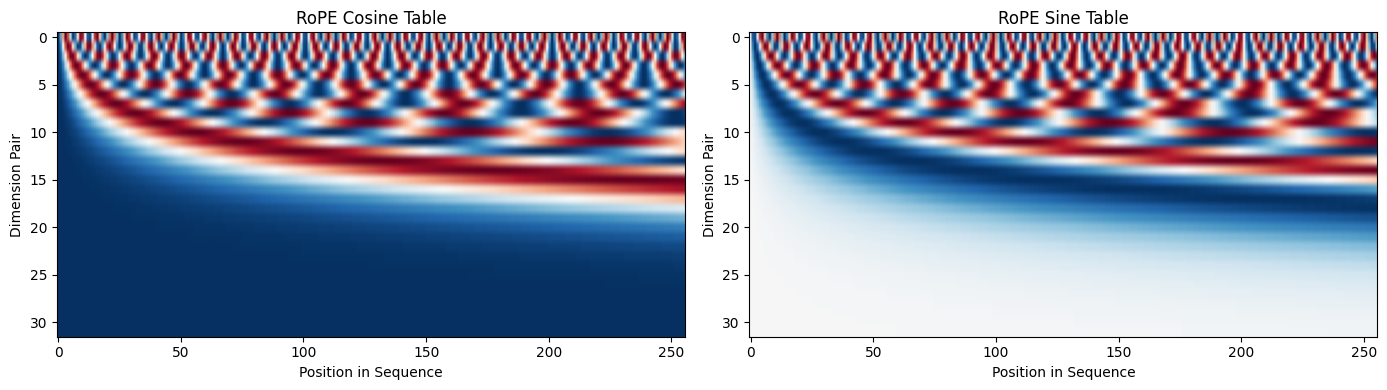

Low dimension pairs (top rows) -> fast oscillation -> short-range patterns
High dimension pairs (bottom rows) -> slow oscillation -> long-range patterns


In [11]:
# ============================================================
# Visualize RoPE Rotation Frequencies
# ============================================================

demo_cos, demo_sin = precompute_rope_freqs(
    head_dim=64,
    max_seq_len=256
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Cosine table
axes[0].imshow(
    demo_cos.T.numpy(),
    aspect="auto",
    cmap="RdBu",
    vmin=-1,
    vmax=1
)
axes[0].set_xlabel("Position in Sequence")
axes[0].set_ylabel("Dimension Pair")
axes[0].set_title("RoPE Cosine Table")

# Sine table
axes[1].imshow(
    demo_sin.T.numpy(),
    aspect="auto",
    cmap="RdBu",
    vmin=-1,
    vmax=1
)
axes[1].set_xlabel("Position in Sequence")
axes[1].set_ylabel("Dimension Pair")
axes[1].set_title("RoPE Sine Table")

plt.tight_layout()
plt.show()

print("Low dimension pairs (top rows) -> fast oscillation -> short-range patterns")
print("High dimension pairs (bottom rows) -> slow oscillation -> long-range patterns")

##Grouped Query Attention (GQA): Reduce KV heads while keeping many Query heads for faster and more memory-efficient attention.

In [12]:
# ============================================================
# Grouped Query Attention (GQA)
# ============================================================

def repeat_kv(x, n_rep):
    """
    Repeat KV heads to match the number of query heads.

    x: [batch, n_kv_heads, seq_len, head_dim]

    Returns:
        [batch, n_heads, seq_len, head_dim]
    """

    if n_rep == 1:
        return x

    b, n_kv, seq, hd = x.shape

    return (
        x[:, :, None, :, :]
        .expand(b, n_kv, n_rep, seq, hd)
        .reshape(b, n_kv * n_rep, seq, hd)
    )


class GroupedQueryAttention(nn.Module):
    """
    Grouped Query Attention with RoPE.
    """

    def __init__(
        self,
        d_model,
        n_heads,
        n_kv_heads
    ):
        super().__init__()

        assert d_model % n_heads == 0
        assert n_heads % n_kv_heads == 0

        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads

        self.head_dim = d_model // n_heads
        self.n_rep = n_heads // n_kv_heads

        # Projections
        self.q_proj = nn.Linear(
            d_model,
            n_heads * self.head_dim,
            bias=False
        )

        self.k_proj = nn.Linear(
            d_model,
            n_kv_heads * self.head_dim,
            bias=False
        )

        self.v_proj = nn.Linear(
            d_model,
            n_kv_heads * self.head_dim,
            bias=False
        )

        self.o_proj = nn.Linear(
            n_heads * self.head_dim,
            d_model,
            bias=False
        )

        self.dropout = nn.Dropout(DROPOUT)

    def forward(
        self,
        x,
        rope_cos,
        rope_sin
    ):
        b, seq, _ = x.shape

        # ----------------------------------------------------
        # Project Q, K, V
        # ----------------------------------------------------
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        # ----------------------------------------------------
        # Split into attention heads
        # ----------------------------------------------------
        q = q.view(
            b,
            seq,
            self.n_heads,
            self.head_dim
        ).transpose(1, 2)

        k = k.view(
            b,
            seq,
            self.n_kv_heads,
            self.head_dim
        ).transpose(1, 2)

        v = v.view(
            b,
            seq,
            self.n_kv_heads,
            self.head_dim
        ).transpose(1, 2)

        # ----------------------------------------------------
        # Apply RoPE
        # ----------------------------------------------------
        q = apply_rope(q, rope_cos, rope_sin)
        k = apply_rope(k, rope_cos, rope_sin)

        # ----------------------------------------------------
        # Repeat KV heads
        # ----------------------------------------------------
        k = repeat_kv(k, self.n_rep)
        v = repeat_kv(v, self.n_rep)

        # ----------------------------------------------------
        # Scaled Dot Product Attention
        # ----------------------------------------------------
        scale = 1.0 / math.sqrt(self.head_dim)

        scores = (
            q @ k.transpose(-2, -1)
        ) * scale

        # ----------------------------------------------------
        # Causal Mask
        # ----------------------------------------------------
        mask = torch.triu(
            torch.ones(
                seq,
                seq,
                device=x.device
            ),
            diagonal=1
        ).bool()

        scores = scores.masked_fill(
            mask,
            float("-inf")
        )

        attn = F.softmax(
            scores,
            dim=-1
        )

        attn = self.dropout(attn)

        out = attn @ v

        # ----------------------------------------------------
        # Merge Heads
        # ----------------------------------------------------
        out = (
            out.transpose(1, 2)
            .contiguous()
            .view(
                b,
                seq,
                self.n_heads * self.head_dim
            )
        )

        out = self.o_proj(out)

        return out

## GQA Shape Demonstration: Understanding Head Sharing and KV Cache Savings

In [13]:
print("GQA Shape Demo:")
print("Config: d_model=256, n_heads=8, n_kv_heads=2")
print("-> head_dim = 256 / 8 = 32")
print("-> 8 Q heads, 2 KV heads")
print("-> each KV head shared by 4 Q heads\n")

demo_gqa = GroupedQueryAttention(
    d_model=256,
    n_heads=8,
    n_kv_heads=2
).to(device)

demo_cos, demo_sin = precompute_rope_freqs(
    head_dim=32,
    max_seq_len=128
)

demo_cos = demo_cos.to(device)
demo_sin = demo_sin.to(device)

demo_in = torch.randn(
    2,
    16,
    256,
    device=device
)

demo_out = demo_gqa(
    demo_in,
    demo_cos,
    demo_sin
)

print(f"Input:  {demo_in.shape}")
print(f"Output: {demo_out.shape}")

q_params = 256 * (8 * 32)
kv_params = 256 * (2 * 32) * 2

print(f"\nQ projection params : {q_params:,} (full 8 heads)")
print(f"KV projection params: {kv_params:,} (only 2 heads)")
print(f"KV cache savings    : {8 // 2}x smaller than standard MHA!")

GQA Shape Demo:
Config: d_model=256, n_heads=8, n_kv_heads=2
-> head_dim = 256 / 8 = 32
-> 8 Q heads, 2 KV heads
-> each KV head shared by 4 Q heads

Input:  torch.Size([2, 16, 256])
Output: torch.Size([2, 16, 256])

Q projection params : 65,536 (full 8 heads)
KV projection params: 32,768 (only 2 heads)
KV cache savings    : 4x smaller than standard MHA!


##SwiGLU: A Gated Feed-Forward Network Used in Modern LLMs

In [14]:
# ============================================================
# SwiGLU Feed-Forward Network
# ============================================================

class SwiGLU(nn.Module):
    """
    SwiGLU Feed-Forward Network

    Two paths:
        gate = SiLU(x @ W_gate)
        up   = x @ W_up

    output:
        (gate * up) @ W_down
    """

    def __init__(self, d_model, hidden_dim):
        super().__init__()

        self.w_gate = nn.Linear(
            d_model,
            hidden_dim,
            bias=False
        )

        self.w_up = nn.Linear(
            d_model,
            hidden_dim,
            bias=False
        )

        self.w_down = nn.Linear(
            hidden_dim,
            d_model,
            bias=False
        )

    def forward(self, x):

        gate = F.silu(
            self.w_gate(x)
        )

        up = self.w_up(x)

        out = self.w_down(
            gate * up
        )

        return F.dropout(
            out,
            p=DROPOUT,
            training=self.training
        )

###Comparing ReLU, GELU and SiLU Activations

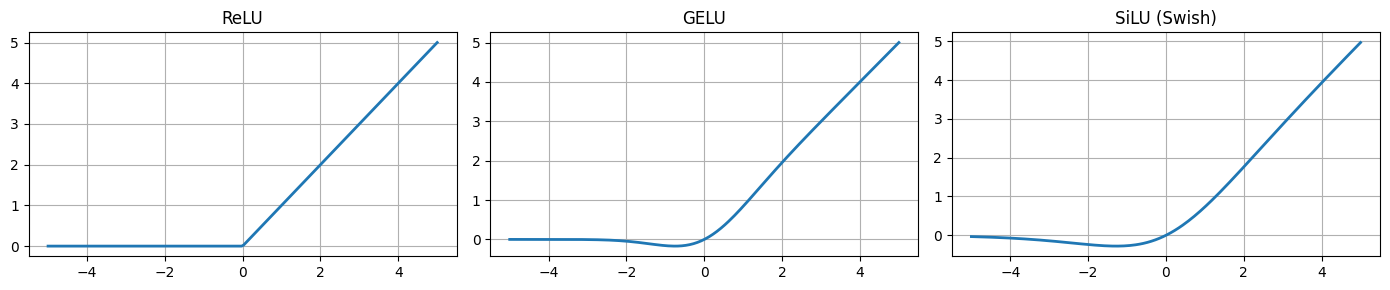

In [15]:
# ============================================================
# Compare Activation Functions
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 3)
)

x_range = torch.linspace(
    -5,
    5,
    200
)

# ReLU
axes[0].plot(
    x_range,
    F.relu(x_range),
    linewidth=2
)
axes[0].set_title("ReLU")
axes[0].grid(True)

# GELU
axes[1].plot(
    x_range,
    F.gelu(x_range),
    linewidth=2
)
axes[1].set_title("GELU")
axes[1].grid(True)

# SiLU
axes[2].plot(
    x_range,
    F.silu(x_range),
    linewidth=2
)
axes[2].set_title("SiLU (Swish)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

##Transformer Block: Combining RMSNorm, GQA Attention, SwiGLU and Residual

In [16]:
# ============================================================
# Transformer Block
# ============================================================

class TransformerBlock(nn.Module):
    """
    One layer of a modern transformer.

    Pre-Norm Architecture:

    x
      ↓
    RMSNorm
      ↓
    GQA Attention
      ↓
    Residual Add

    x
      ↓
    RMSNorm
      ↓
    SwiGLU FFN
      ↓
    Residual Add
    """

    def __init__(
        self,
        d_model,
        n_heads,
        n_kv_heads,
        ffn_hidden_dim
    ):
        super().__init__()

        # Attention path
        self.attn_norm = RMSNorm(d_model)

        self.attention = GroupedQueryAttention(
            d_model,
            n_heads,
            n_kv_heads
        )

        # Feed-forward path
        self.ffn_norm = RMSNorm(d_model)

        self.ffn = SwiGLU(
            d_model,
            ffn_hidden_dim
        )

    def forward(
        self,
        x,
        rope_cos,
        rope_sin
    ):

        # ----------------------------------
        # Attention + Residual
        # ----------------------------------
        x = x + self.attention(
            self.attn_norm(x),
            rope_cos,
            rope_sin
        )

        # ----------------------------------
        # FFN + Residual
        # ----------------------------------
        x = x + self.ffn(
            self.ffn_norm(x)
        )

        return x

##MiniLLM: Complete Modern Transformer Language Model

In [17]:
# ============================================================
# MiniLLM
# ============================================================

class MiniLLM(nn.Module):
    """
    A small but modern language model.

    Features:
    - RMSNorm
    - RoPE
    - Grouped Query Attention
    - SwiGLU
    - Weight Tying

    Training Objective:
    Next Character Prediction
    """

    def __init__(
        self,
        vocab_size,
        d_model,
        n_layers,
        n_heads,
        n_kv_heads,
        ffn_hidden_dim,
        max_seq_len
    ):
        super().__init__()

        self.d_model = d_model
        self.max_seq_len = max_seq_len

        # ----------------------------------------------------
        # Token Embedding
        # ----------------------------------------------------
        self.token_emb = nn.Embedding(
            vocab_size,
            d_model
        )

        # ----------------------------------------------------
        # Transformer Blocks
        # ----------------------------------------------------
        self.layers = nn.ModuleList([
            TransformerBlock(
                d_model,
                n_heads,
                n_kv_heads,
                ffn_hidden_dim
            )
            for _ in range(n_layers)
        ])

        # ----------------------------------------------------
        # Final RMSNorm
        # ----------------------------------------------------
        self.final_norm = RMSNorm(
            d_model
        )

        # ----------------------------------------------------
        # Output Projection
        # ----------------------------------------------------
        self.lm_head = nn.Linear(
            d_model,
            vocab_size,
            bias=False
        )

        # ----------------------------------------------------
        # Weight Tying
        # ----------------------------------------------------
        self.lm_head.weight = self.token_emb.weight

        # ----------------------------------------------------
        # Precompute RoPE Tables
        # ----------------------------------------------------
        head_dim = d_model // n_heads

        rope_cos, rope_sin = precompute_rope_freqs(
            head_dim,
            max_seq_len
        )

        self.register_buffer(
            "rope_cos",
            rope_cos
        )

        self.register_buffer(
            "rope_sin",
            rope_sin
        )

        # ----------------------------------------------------
        # Initialize Weights
        # ----------------------------------------------------
        self.apply(
            self._init_weights
        )

    def _init_weights(
        self,
        module
    ):
        if isinstance(module, nn.Linear):
            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

        elif isinstance(module, nn.Embedding):
            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

    def forward(
        self,
        idx,
        targets=None
    ):
        b, seq_len = idx.shape

        # ----------------------------------------------------
        # Token Embeddings
        # ----------------------------------------------------
        x = self.token_emb(idx)

        # ----------------------------------------------------
        # Transformer Layers
        # ----------------------------------------------------
        for layer in self.layers:
            x = layer(
                x,
                self.rope_cos,
                self.rope_sin
            )

        # ----------------------------------------------------
        # Final RMSNorm
        # ----------------------------------------------------
        x = self.final_norm(x)

        # ----------------------------------------------------
        # Vocabulary Projection
        # ----------------------------------------------------
        logits = self.lm_head(x)

        loss = None

        if targets is not None:

            loss = F.cross_entropy(
                logits.view(
                    -1,
                    logits.size(-1)
                ),
                targets.view(-1)
            )

        return logits, loss

##Model Summary: Display Architecture Configuration and Parameter Count

In [18]:
# ============================================================
# Model Configuration
# ============================================================

config = {
    "vocab_size": vocab_size,
    "d_model": 256,
    "n_layers": 8,
    "n_heads": 8,
    "n_kv_heads": 2,
    "ffn_hidden_dim": 680,
    "max_seq_len": 256
}

# ============================================================
# Create Model
# ============================================================

model = MiniLLM(**config).to(device)

# ============================================================
# Parameter Statistics
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

head_dim = (
    config["d_model"]
    // config["n_heads"]
)

model_size_mb = (
    total_params * 4
) / (1024 ** 2)

# ============================================================
# Model Summary
# ============================================================

print("=" * 50)
print("MODEL SUMMARY")
print("=" * 50)

print(f"Vocabulary Size     : {config['vocab_size']}")
print(f"Embedding Dimension : {config['d_model']}")
print(f"Layers              : {config['n_layers']}")
print(f"Query Heads         : {config['n_heads']}")
print(f"KV Heads            : {config['n_kv_heads']}")
print(f"FFN Hidden Dim      : {config['ffn_hidden_dim']}")
print(f"Context Length      : {config['max_seq_len']}")
print(f"Head Dimension      : {head_dim}")

print()

print(f"Total Parameters    : {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Model Size (Approx) : {model_size_mb:.2f} MB")

print("=" * 50)

MODEL SUMMARY
Vocabulary Size     : 65
Embedding Dimension : 256
Layers              : 8
Query Heads         : 8
KV Heads            : 2
FFN Hidden Dim      : 680
Context Length      : 256
Head Dimension      : 32

Total Parameters    : 5,509,632
Trainable Parameters: 5,509,632
Model Size (Approx) : 21.02 MB


##Training Setup: Hyperparameters, Optimizer and Loss Evaluation Function

In [19]:
# ============================================================
# Training Hyperparameters
# ============================================================

BATCH_SIZE = 64
CONTEXT_LEN = config["max_seq_len"]

LEARNING_RATE = 3e-4

MAX_STEPS = 1000

EVAL_INTERVAL = 250
EVAL_STEPS = 20

LOG_INTERVAL = 50

# ============================================================
# Optimizer
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

# ============================================================
# Loss Estimation
# ============================================================

@torch.no_grad()
def estimate_loss():
    """
    Estimate average loss on both
    training and validation splits.
    """

    model.eval()

    out = {}

    for split in ["train", "val"]:

        losses = []

        for _ in range(EVAL_STEPS):

            xb, yb = get_batch(
                split,
                BATCH_SIZE,
                CONTEXT_LEN
            )

            _, loss = model(
                xb,
                yb
            )

            losses.append(
                loss.item()
            )

        out[split] = (
            sum(losses)
            / len(losses)
        )

    model.train()

    return out

##Training Loop: Train the Model by Predicting the Next Character

In [20]:
# ============================================================
# Training Loop
# ============================================================

print("=" * 60)
print("Starting Training...")
print("=" * 60)

start_time = time.time()

for step in range(MAX_STEPS):

    # --------------------------------------------------------
    # Sample Batch
    # --------------------------------------------------------
    xb, yb = get_batch(
        "train",
        BATCH_SIZE,
        CONTEXT_LEN
    )

    # --------------------------------------------------------
    # Forward Pass
    # --------------------------------------------------------
    logits, loss = model(
        xb,
        yb
    )

    # --------------------------------------------------------
    # Backward Pass
    # --------------------------------------------------------
    optimizer.zero_grad(
        set_to_none=True
    )

    loss.backward()

    optimizer.step()

    # --------------------------------------------------------
    # Training Log
    # --------------------------------------------------------
    if step % LOG_INTERVAL == 0:

        print(
            f"Step {step:4d} | "
            f"Train Loss: {loss.item():.4f}"
        )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------
    if (
        step % EVAL_INTERVAL == 0
        or step == MAX_STEPS - 1
    ):

        losses = estimate_loss()

        elapsed = (
            time.time()
            - start_time
        )

        print(
            f"\nStep {step:4d}"
            f" | Train Loss: {losses['train']:.4f}"
            f" | Val Loss: {losses['val']:.4f}"
            f" | Time: {elapsed:.1f}s\n"
        )

print("=" * 60)
print("Training Complete!")
print("=" * 60)

Starting Training...
Step    0 | Train Loss: 4.1849

Step    0 | Train Loss: 3.7471 | Val Loss: 3.7605 | Time: 6.0s

Step   50 | Train Loss: 2.7710
Step  100 | Train Loss: 2.3841
Step  150 | Train Loss: 2.1216
Step  200 | Train Loss: 1.8762
Step  250 | Train Loss: 1.7504

Step  250 | Train Loss: 1.6826 | Val Loss: 1.8241 | Time: 124.8s

Step  300 | Train Loss: 1.6576
Step  350 | Train Loss: 1.5966
Step  400 | Train Loss: 1.5100
Step  450 | Train Loss: 1.4883
Step  500 | Train Loss: 1.4589

Step  500 | Train Loss: 1.3748 | Val Loss: 1.5688 | Time: 252.3s

Step  550 | Train Loss: 1.3987
Step  600 | Train Loss: 1.3973
Step  650 | Train Loss: 1.3663
Step  700 | Train Loss: 1.3644
Step  750 | Train Loss: 1.3825

Step  750 | Train Loss: 1.2724 | Val Loss: 1.5195 | Time: 380.9s

Step  800 | Train Loss: 1.3183
Step  850 | Train Loss: 1.3144
Step  900 | Train Loss: 1.3148
Step  950 | Train Loss: 1.2733

Step  999 | Train Loss: 1.2135 | Val Loss: 1.4850 | Time: 508.4s

Training Complete!


##: Save the Trained Model

In [21]:
# ============================================================
# Save Model Checkpoint
# ============================================================

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": config,
        "vocab_size": vocab_size,
    },
    "mini_llm_shakespeare.pt"
)

print("Model saved successfully!")

Model saved successfully!


## Add Text Generation Function

In [22]:
# ============================================================
# Text Generation
# ============================================================

@torch.no_grad()
def generate(
    model,
    start_text,
    max_new_tokens=300,
    temperature=0.8,
    top_k=20
):
    model.eval()

    idx = torch.tensor(
        [encode(start_text)],
        dtype=torch.long,
        device=device
    )

    for _ in range(max_new_tokens):

        idx_cond = idx[:, -config["max_seq_len"]:]

        logits, _ = model(idx_cond)

        logits = logits[:, -1, :] / temperature

        if top_k is not None:
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = -float("inf")

        probs = F.softmax(logits, dim=-1)

        next_token = torch.multinomial(
            probs,
            num_samples=1
        )

        idx = torch.cat(
            [idx, next_token],
            dim=1
        )

    return decode(idx[0].tolist())

## Generate Text

In [26]:
prompt = "SANSKAR:"

generated_text = generate(
    model,
    prompt,
    max_new_tokens=300,
    temperature=1.0,
    top_k=20
)

print(generated_text)

SANSKAR:
Drumber sounds, now likning with thy neighbours.

RICHARD:
But sense you had not life advised the glory,
To the forfeit of a dear sives in a victory,
And but recious fear that from such maarge it!
I shall be gone, would thy kingdom spring big son?

First Edward:
O, last in this town bonds; and she 
